In [152]:
# Import the needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [153]:
randome_state = 13

In [154]:
# Read the dataset
breast_cancer_dataset = pd.read_csv('../data/breast_cancer/wdbc.data')
# Set column names (needed since the data file doesn't have a header row)
breast_cancer_dataset.columns = [
    'ID',
    'Diagnosis',
    'radius1',
    'texture1',
    'perimeter1',
    'area1',
    'smoothness1',
    'compactness1',
    'concavity1',
    'concave_points1',
    'symmetry1',
    'fractal_dimensions1',
    'radius2',
    'texture2',
    'perimeter2',
    'area2',
    'smoothness2',
    'compactness2',
    'concavity2',
    'concave_points2',
    'symmetry2',
    'fractal_dimensions2',
    'radius3',
    'texture3',
    'perimeter3',
    'area3',
    'smoothness3',
    'compactness3',
    'concavity3',
    'concave_points3',
    'symmetry3',
    'fractal_dimensions3',
]
# Show the first 5 rows to validate that the data import has been successful
breast_cancer_dataset.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [155]:
# Remove the ID column since this has no predictive value
breast_cancer_dataset = breast_cancer_dataset.drop('ID', axis=1)

# Separate the dataset into features (inputs) and targets (output/ground truth)
features = breast_cancer_dataset.drop('Diagnosis', axis=1)
targets = breast_cancer_dataset['Diagnosis']

In [156]:
# Mean normalization using pandas
features_normalized = (features - features.mean())/features.std()

In [157]:
# Stratified (Correct way for classification datasets)

# The following statements would be sufficient if the dataset wasn't already
# split into features and targets to perform mean normalization

# train_data = breast_cancer_dataset.groupby('Diagnosis').sample(frac=0.6)
# test_validation_data = breast_cancer_dataset.drop(train_data.index, axis=0)
# validation_data = test_validation_data.groupby('Diagnosis').sample(frac=0.5)
# test_data = test_validation_data.drop(validation_data.index, axis=0)

# Split the features and targets using the indices from the dataset

train_indices = breast_cancer_dataset.groupby('Diagnosis').sample(frac=0.6).index
train_features = features_normalized.iloc[train_indices]
train_targets = targets.iloc[train_indices]

testvalidation_dataset = breast_cancer_dataset.drop(train_indices, axis=0)
validation_indices = testvalidation_dataset.groupby('Diagnosis').sample(frac=0.5).index

validation_features = features_normalized.iloc[validation_indices]
validation_targets = targets.iloc[validation_indices]

test_indices = testvalidation_dataset.drop(validation_indices, axis=0).index
test_features = features_normalized.iloc[test_indices]
test_targets = targets.iloc[test_indices]

print(train_targets.value_counts()/train_targets.count())
print(validation_targets.value_counts()/validation_targets.count())
print(test_targets.value_counts()/test_targets.count())

Diagnosis
B    0.627566
M    0.372434
Name: count, dtype: float64
Diagnosis
B    0.631579
M    0.368421
Name: count, dtype: float64
Diagnosis
B    0.628319
M    0.371681
Name: count, dtype: float64


array([[<Axes: title={'center': 'radius1'}>,
        <Axes: title={'center': 'texture1'}>,
        <Axes: title={'center': 'perimeter1'}>,
        <Axes: title={'center': 'area1'}>,
        <Axes: title={'center': 'smoothness1'}>],
       [<Axes: title={'center': 'compactness1'}>,
        <Axes: title={'center': 'concavity1'}>,
        <Axes: title={'center': 'concave_points1'}>,
        <Axes: title={'center': 'symmetry1'}>,
        <Axes: title={'center': 'fractal_dimensions1'}>],
       [<Axes: title={'center': 'radius2'}>,
        <Axes: title={'center': 'texture2'}>,
        <Axes: title={'center': 'perimeter2'}>,
        <Axes: title={'center': 'area2'}>,
        <Axes: title={'center': 'smoothness2'}>],
       [<Axes: title={'center': 'compactness2'}>,
        <Axes: title={'center': 'concavity2'}>,
        <Axes: title={'center': 'concave_points2'}>,
        <Axes: title={'center': 'symmetry2'}>,
        <Axes: title={'center': 'fractal_dimensions2'}>],
       [<Axes: title={'c

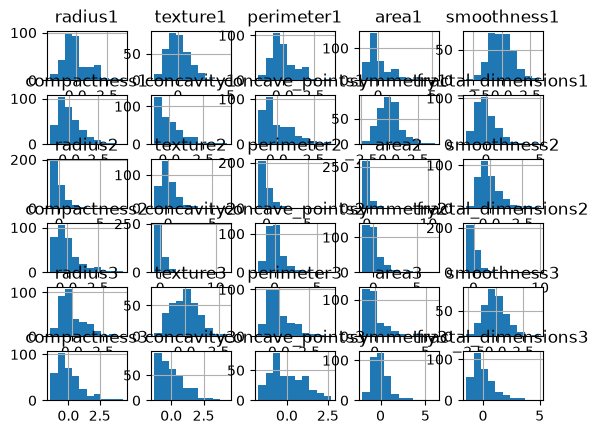

In [158]:
# Add distribution plots to check for validity. The goal is to make 
# sure that the distributions are similar between the partitions
train_features.hist()

array([[<Axes: title={'center': 'radius1'}>,
        <Axes: title={'center': 'texture1'}>,
        <Axes: title={'center': 'perimeter1'}>,
        <Axes: title={'center': 'area1'}>,
        <Axes: title={'center': 'smoothness1'}>],
       [<Axes: title={'center': 'compactness1'}>,
        <Axes: title={'center': 'concavity1'}>,
        <Axes: title={'center': 'concave_points1'}>,
        <Axes: title={'center': 'symmetry1'}>,
        <Axes: title={'center': 'fractal_dimensions1'}>],
       [<Axes: title={'center': 'radius2'}>,
        <Axes: title={'center': 'texture2'}>,
        <Axes: title={'center': 'perimeter2'}>,
        <Axes: title={'center': 'area2'}>,
        <Axes: title={'center': 'smoothness2'}>],
       [<Axes: title={'center': 'compactness2'}>,
        <Axes: title={'center': 'concavity2'}>,
        <Axes: title={'center': 'concave_points2'}>,
        <Axes: title={'center': 'symmetry2'}>,
        <Axes: title={'center': 'fractal_dimensions2'}>],
       [<Axes: title={'c

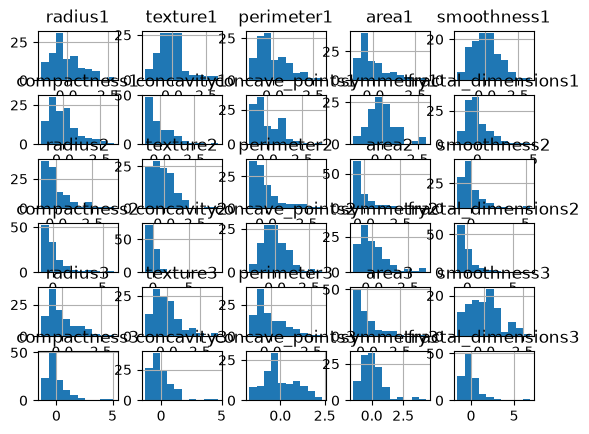

In [159]:
validation_features.hist()

array([[<Axes: title={'center': 'radius1'}>,
        <Axes: title={'center': 'texture1'}>,
        <Axes: title={'center': 'perimeter1'}>,
        <Axes: title={'center': 'area1'}>,
        <Axes: title={'center': 'smoothness1'}>],
       [<Axes: title={'center': 'compactness1'}>,
        <Axes: title={'center': 'concavity1'}>,
        <Axes: title={'center': 'concave_points1'}>,
        <Axes: title={'center': 'symmetry1'}>,
        <Axes: title={'center': 'fractal_dimensions1'}>],
       [<Axes: title={'center': 'radius2'}>,
        <Axes: title={'center': 'texture2'}>,
        <Axes: title={'center': 'perimeter2'}>,
        <Axes: title={'center': 'area2'}>,
        <Axes: title={'center': 'smoothness2'}>],
       [<Axes: title={'center': 'compactness2'}>,
        <Axes: title={'center': 'concavity2'}>,
        <Axes: title={'center': 'concave_points2'}>,
        <Axes: title={'center': 'symmetry2'}>,
        <Axes: title={'center': 'fractal_dimensions2'}>],
       [<Axes: title={'c

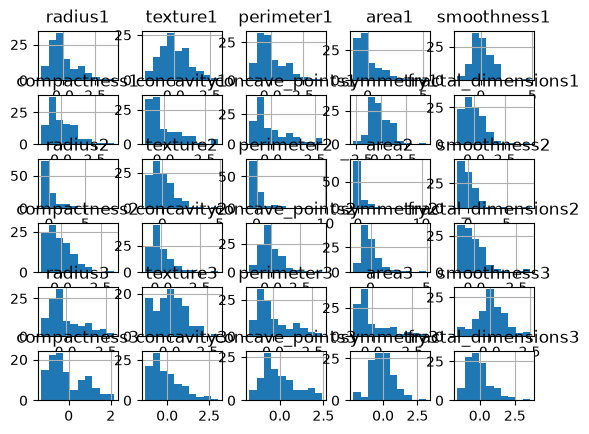

In [160]:
test_features.hist()

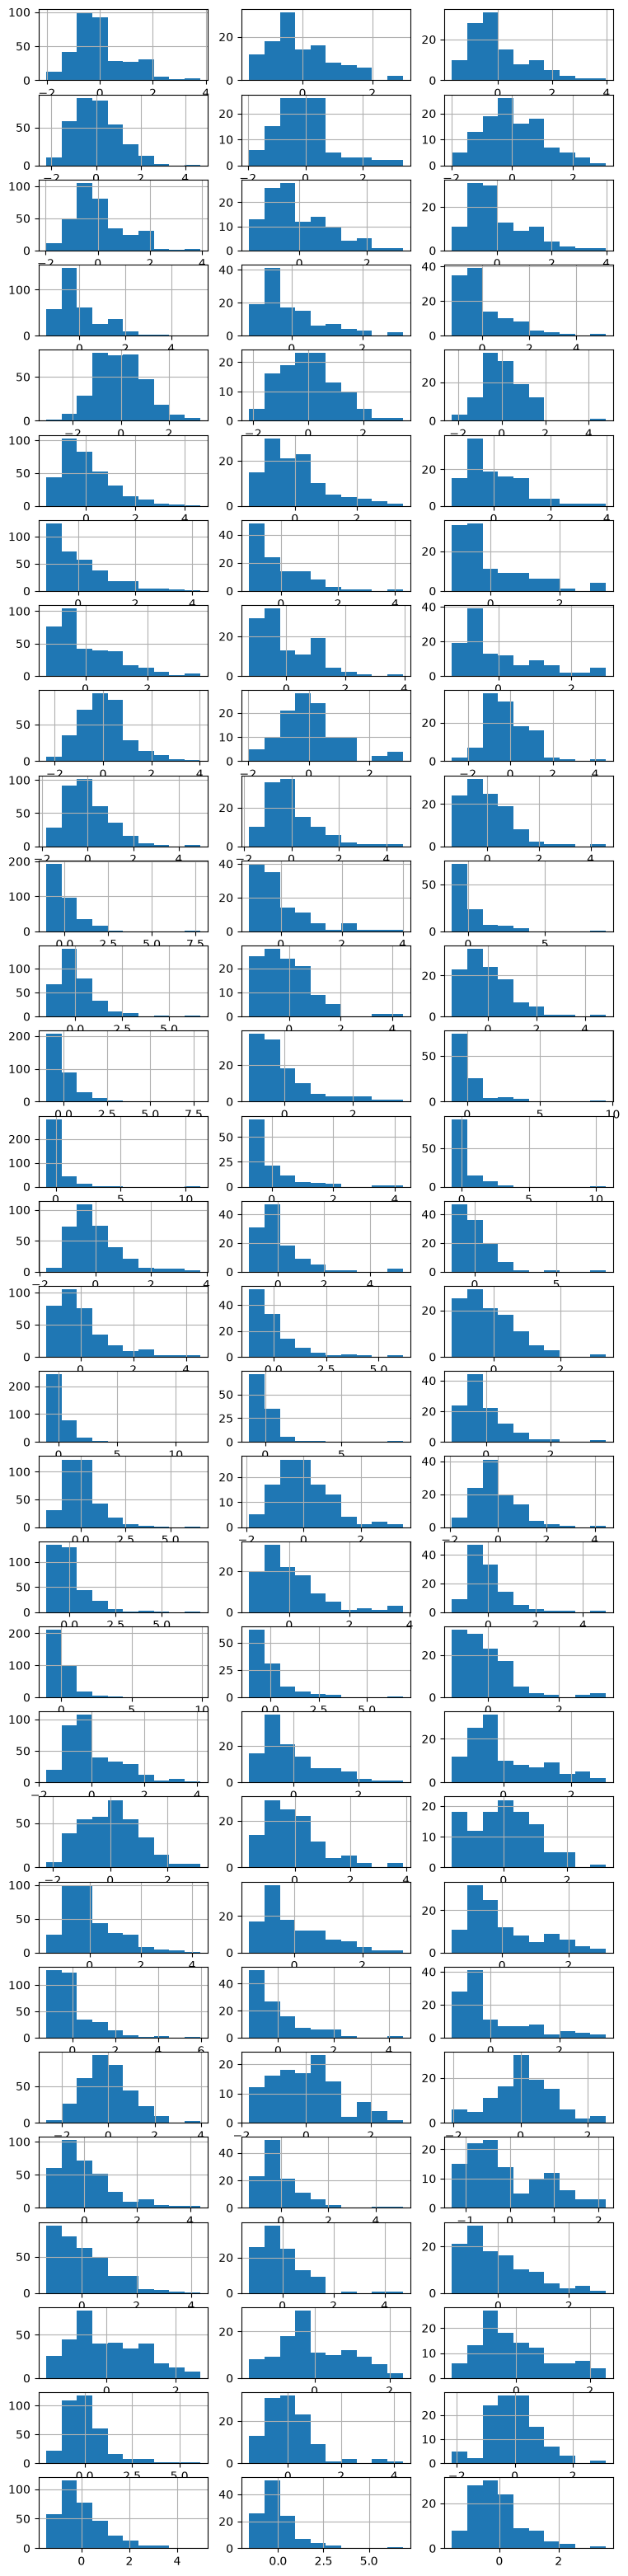

In [161]:
# It is likely easier to validate with the corresponding features 
# side by side
fig, axs = plt.subplots(30, 3, figsize=(9, 40))
for i, feature in enumerate(train_features.columns):
    train_features[feature].hist(ax=axs[i, 0])
    validation_features[feature].hist(ax=axs[i, 1])
    test_features[feature].hist(ax=axs[i, 2])

In [162]:
# Create functions to perform evaluation 

# Used to evaluate hyperparameter tuning
def validation(model):
    train_predictions = model.predict(train_features)
    validation_predictions = model.predict(validation_features)
    print(f'Training Accuracy: {accuracy_score(train_targets, train_predictions):.2f} Validation: {accuracy_score(validation_targets, validation_predictions):.2f}')    
# Used for final testing
def test(model):
    train_predictions = model.predict(train_features)
    validation_predictions = model.predict(validation_features)
    test_predictions = model.predict(test_features)
    print(f'Training Accuracy: {accuracy_score(train_targets, train_predictions):.2f} Validation Accuracy: {accuracy_score(validation_targets, validation_predictions):.2f} Testing: {accuracy_score(test_targets, test_predictions):.2f}')    

In [163]:
# Train a decision tree with default hyperparameters
dt_default = DecisionTreeClassifier()
dt_default.fit(train_features, train_targets)
# Perform validation
validation(dt_default)


Training Accuracy: 1.00 Validation: 0.91


In [164]:
# Tune max_depth hyperparameter

# Start with max_depth=3
dt_maxdepth_3 = DecisionTreeClassifier(max_depth=3)
dt_maxdepth_3.fit(train_features, train_targets)
validation(dt_maxdepth_3)

Training Accuracy: 0.97 Validation: 0.94


In [165]:
# Final testing of the best model
test(dt_maxdepth_3)

Training Accuracy: 0.97 Validation Accuracy: 0.94 Testing: 0.96


In [ ]:
# The training and tuning setup above will produce different 
# results with each new run due to random effects

# The simplest way to handle this is to use a fixed random state. However, 
# this will make it impossible to confidently conclude which model performs 
# the best

global_random_state = 13

# The data splitting is random and needs the global seed

train_indices = breast_cancer_dataset.groupby('Diagnosis').sample(frac=0.6, random_state=global_random_state).index
train_features = features_normalized.iloc[train_indices]
train_targets = targets.iloc[train_indices]

testvalidation_dataset = breast_cancer_dataset.drop(train_indices, axis=0)
validation_indices = testvalidation_dataset.groupby('Diagnosis').sample(frac=0.5, random_state=global_random_state).index

validation_features = features_normalized.iloc[validation_indices]
validation_targets = targets.iloc[validation_indices]

test_indices = testvalidation_dataset.drop(validation_indices, axis=0).index
test_features = features_normalized.iloc[test_indices]
test_targets = targets.iloc[test_indices]

# The model also needs the global random seed, though this isn't always used 
# internally (depends on model type and the hyperparameters specified)
dt_default = DecisionTreeClassifier(random_state=global_random_state)
 
# A better approach would be to run multiple times to calculate the mean and 
# standard deviation